In [1]:
# Import the FEMSystem Class from directory above
import sys
from VisualizeVF import VisualizeVF
sys.path.append('..')
from FEMSystem import FEMSystem

import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np
from Units2D import Units2D
from RabiLondon2D import RabiLondon2D
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

---- Successfully initialed RabiLondon2D Object ----
Integrated Area: 3245.99609375 | Area: 3200.0 | Error: 1.42%
EJ: 1.5952848196029663 | EC: 9.368083953857422 | EJ/EC: 0.17028933763504028
Qubit Frequency: 1.592400074005127 (non-dimensional energy units)
Effective mass: 1.352951108801842e-32 kg | 0.007433797301109022 times (2m_e)
Computed kappa: 3.0, c_bar: 7.686986102564269e+18



Using xi = 0.39 A
Units check: Plasma frequencies must be equal (in rad/s): 2.5623287008547564e+18 | 2.562328700854757e+18
kappa: 3, c_bar: 7.686986102564269e+18
n_s = 7.661529891669679e+30 | n_s xi^3: 0.45447429164395375
deltaZ: 0.06876076507421461
lambda_L: 1.17e-10
========Step 1 Finished =========


========Step 2: Solve Helmholtz Equation =========
0.13270000616709393
Qubit Frequency (in nondim units): 1.592400074005127 | (in rad/s):1.0200631032166438e+18
Expected effective london penetration depth: 3.270317881423663
saddle residual A: 9.369540898529874e-14 gauge residual: 7.924682275339639e-14
A1_mat_

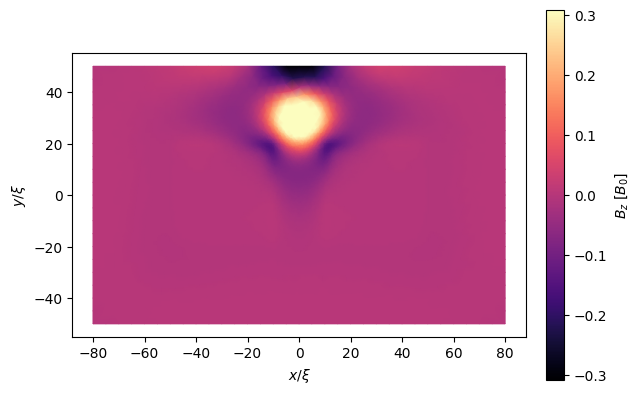

In [2]:
pickled_obj = {}
with open('./allplots/firsttest3rabi.pkl', 'rb') as f:
    pickled_obj = pickle.load(f)

rabioutput = pickled_obj["rabioutput"]
t_grid = pickled_obj["t_grid"]
A_sol = pickled_obj["A_sol"]
rabilondon = pickled_obj["rabilondon"]


'''
Get basis_edge
'''

with open('./../2D/allplots/rabilondonfine11/results.pkl', 'rb') as f:
    pickled_obj2 = pickle.load(f)

rabilondon = RabiLondon2D(pickled_obj2)

# Now define all physical and material parameters. Only need \xi and desired kappa
xi = .39e-10 * 1
kappa = 3
units2d = Units2D(xi,kappa)
# Check units, if transition frequency in nondim units is 4, then must equal plasma frequency
kappa_computed,c_bar = units2d.kappa_cbar_from_xi(xi)
print(f"Computed kappa: {kappa_computed}, c_bar: {c_bar}")
plasma_freq1,plasma_freq2 = c_bar/kappa, units2d.convert_energy_to_rad_s(4,xi)
print("\n\n")
print(f"Using xi = {xi*1e10} A")
print(f"Units check: Plasma frequencies must be equal (in rad/s): {plasma_freq1} | {plasma_freq2}")
print(f"kappa: {kappa}, c_bar: {c_bar}")

n_s  = units2d.n_sfromxi(xi)
print(f"n_s = {n_s} | n_s xi^3: {n_s*xi**3}")
deltaZ = units2d.compute_dz(n_s,rabilondon.N,rabilondon.area)
print(f"deltaZ: {deltaZ}")

# London penetration depth from n_s
lambda_L = units2d.london_from_n_s(n_s)
print(f"lambda_L: {lambda_L}")
print("========Step 1 Finished =========\n\n")

'''
Step 2: Solve Helmholtz Equation
'''
print("========Step 2: Solve Helmholtz Equation =========")
# Define all Parameters
omega_d_nondim = rabilondon.omega_q # on resonance drive
omega_d_rad_s = units2d.convert_energy_to_rad_s(omega_d_nondim,xi)   #convert to rad/s
print(omega_d_rad_s/c_bar)
print(f"Qubit Frequency (in nondim units): {omega_d_nondim} | (in rad/s):{omega_d_rad_s}")

# Compute expected effective london penetration depth
wavevec_mag = np.sqrt(1/kappa**2-omega_d_rad_s**2/c_bar**2)
lambda_eff = 1/wavevec_mag
print(f"Expected effective london penetration depth: {lambda_eff}")

# All from parameters
source_obj = {
    "source_coord": (0,30),
    "sigma": 10,
    "m": 100
}

# Run Solver
A_sol, basis_edge = rabilondon.helmholtz_solver(omega_d_rad_s,c_bar,kappa,source_obj)

vis = VisualizeVF(rabilondon.mesh, basis_edge, A_sol)


H_of_t, A1_mat, A2_mat = rabilondon.rabi_hamiltonian(basis_edge,A_sol,omega_d_nondim)

# Get 2 x 2 Matrices for TLS
A1_mat_TLS = rabilondon.TLS_matrix(A1_mat)
A2_mat_TLS = rabilondon.TLS_matrix(A2_mat)
print(f"A1_mat_TLS: {A1_mat_TLS}")
print(f"A2_mat_TLS: {A2_mat_TLS}")

# Get Pauli Decomposition
A1_mat_TLS_decomposed = rabilondon.pauli_decompose(A1_mat_TLS)
A2_mat_TLS_decomposed = rabilondon.pauli_decompose(A2_mat_TLS)
print(f"Order is identity, sigma_x, sigma_y, sigma_z")
print(f"A_1 Decomposed: {A1_mat_TLS_decomposed}")
print(f"A_2 Decomposed: {A2_mat_TLS_decomposed}")
a1_off_diag_max, a2_off_diag_max = np.max(np.abs(A1_mat_TLS - np.diag(np.diag(A1_mat_TLS)))), np.max(np.abs(A2_mat_TLS - np.diag(np.diag(A2_mat_TLS))))     
detuning_max = max(np.abs(A1_mat_TLS_decomposed[3]), np.abs(A2_mat_TLS_decomposed[3]))
a2z_detuning = np.abs(A2_mat_TLS_decomposed[3])
print(f"A1 Off Diagonal Max: {a1_off_diag_max}")
print(f"A2 Off Diagonal Max: {a2_off_diag_max}\n")
print(f"Check that A1 off diagonal max is much much larger for Rabi Oscillations!! It is {a1_off_diag_max/a2_off_diag_max} times larger.")
print(f"Check that detuning is much lower too! Off diagonal of A1 is {a1_off_diag_max/detuning_max} times larger than the detuning (A1z and A2z).\n\n")

rabi_freq = np.sqrt(np.abs(A1_mat_TLS_decomposed[1])**2 + np.abs(A1_mat_TLS_decomposed[2])**2)  
rabi_period = float(2*np.pi/rabi_freq)
drive_period = float(2*np.pi/omega_d_nondim) # Remember Hamiltonian is nondimmed, so 1/energy or 1/time is nondimmed
print(f"Approx Rabi Frequency (Assuming x and y components of A2 are trivial): {rabi_freq}")
print(f"Rabi Period (nondim): {rabi_period} s")
print(f"Drive Period (nondim): {drive_period} s")
print(f"Iterations: {rabi_period/drive_period*30}\n\n")

print(f"Direct Detuning from A2Z Only (Since A2 has DC term): {a2z_detuning} | Fixing Drive Frequency by Adding Detuning")
omega_d_nondim_new = omega_d_nondim - 2*a2z_detuning
H_of_t_new, A1_mat_new, A2_mat_new = rabilondon.rabi_hamiltonian(basis_edge,A_sol,omega_d_nondim_new)
print("========Step 3 Finished =========\n\n")


fig, ax2 = plt.subplots()
vis.visualize_vf(None, ax2, bz_symmetric_percentile=99.0)

Fitted omega: 0.000277154249
Omega std err: 9.03e-09
RMSE: 0.011
Fit parameters: A = 0.01, tau = 6.21, C = -0.058


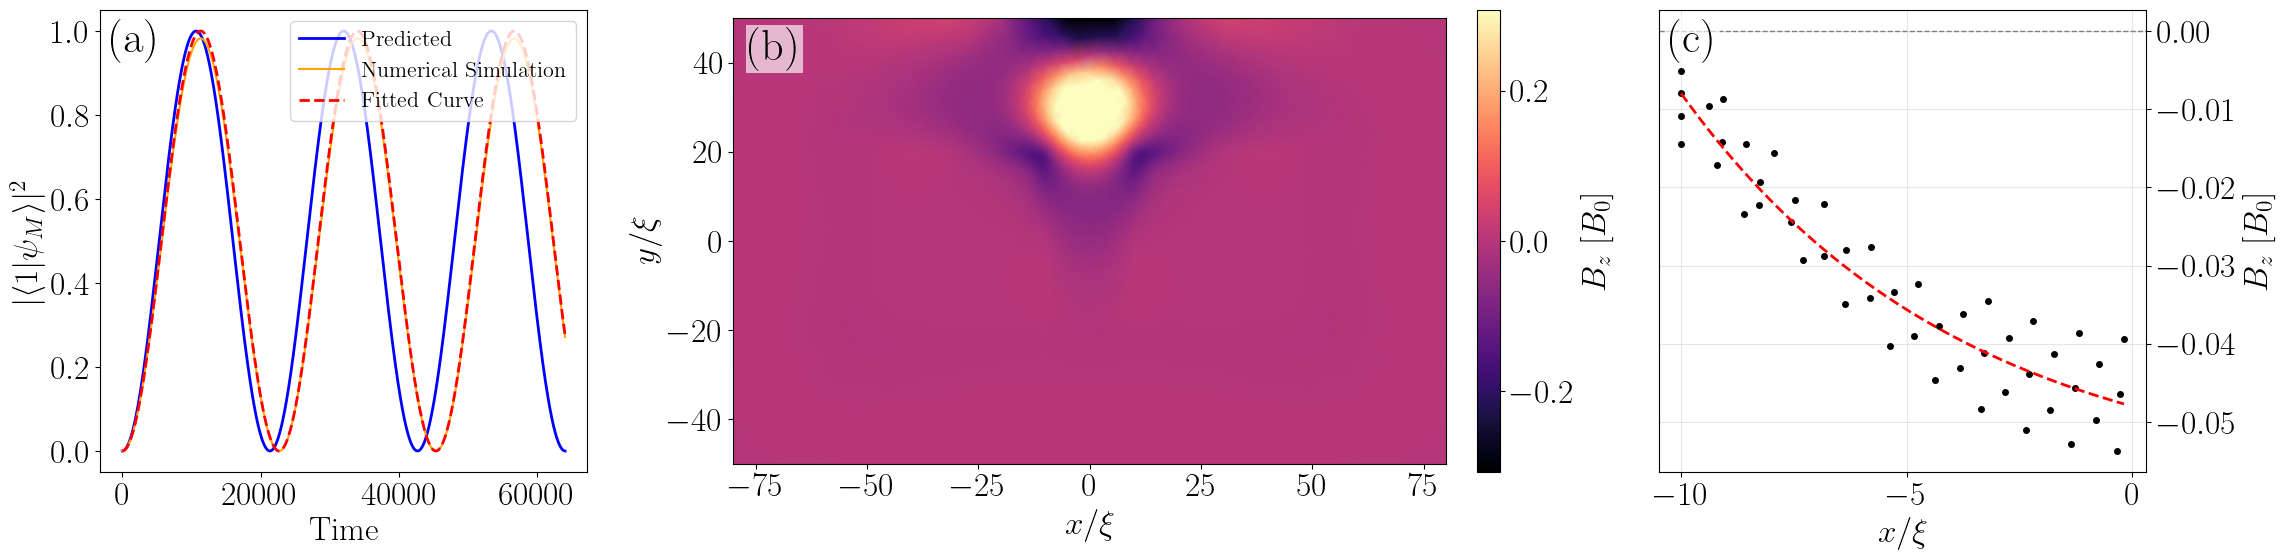

: 

In [ ]:
def figuregen(rabilondon, rabioutput, A_sol,vis,t_grid,lpfitmin,lpfitmax,tol):
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 24,
    })

    # Create three plots side-by-side with dynamic middle-column width
    x_p1_tmp, y_p1_tmp, _ = vis._p1_plot_triangulation()
    x_span = float(np.max(x_p1_tmp) - np.min(x_p1_tmp))
    y_span = float(np.max(y_p1_tmp) - np.min(y_p1_tmp))

    mid_ratio = (x_span / y_span) if y_span > 0 else 1.0
    mid_ratio = float(np.clip(mid_ratio, 0.7, 2.0))  # optional stability clamp

    fig = plt.figure(figsize=(22, 6), constrained_layout=False)
    gs = fig.add_gridspec(1, 3, width_ratios=[1.0, mid_ratio, 1.0], wspace=0.25)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])


    '''
    Plot 1: Rabi Oscillations
    '''
    # Rabi Oscillations plot + fit state-1 population to (1 - cos(omega * t))/2
    skip = 10
    number_of_states = 5
    eigenvalues, eigenvectors = rabilondon.eigenvalues, rabilondon.eigenvectors
    populations = [[] for _ in range(number_of_states)]
    for i in range(0, len(rabioutput), skip):
        psi = rabioutput[i]
        psi /= jnp.linalg.norm(psi)

        for j in range(number_of_states):
            p_j = jnp.abs(jnp.vdot(eigenvectors[:, j], psi))**2
            populations[j].append(p_j)

    # Convert to arrays for fitting
    sample_t = np.asarray(t_grid[::skip], dtype=float)
    state1_pop = np.asarray(populations[1], dtype=float)


    # (1 - cos(omega * t)) / 2
    def rabi_model(t, omega):
        return 0.5 * (1.0 - np.cos(omega * t))

    # Initial guess from your previously computed rabi_freq
    omega0 = float(np.real(rabi_freq)) if np.ndim(rabi_freq) == 0 else float(np.real(rabi_freq[0]))

    try:
        popt, pcov = curve_fit(rabi_model, sample_t, state1_pop, p0=[max(omega0, 1e-12)], bounds=(0.0, np.inf))
        omega_fit = float(popt[0])
        omega_fit_std = float(np.sqrt(np.diag(pcov))[0]) if np.isfinite(pcov).all() else np.nan
        fit_vals = rabi_model(sample_t, omega_fit)
        rmse = float(np.sqrt(np.mean((state1_pop - fit_vals) ** 2)))

        print(f"Fitted omega: {omega_fit:.9g}")
        print(f"Omega std err: {omega_fit_std:.3g}")
        print(f"RMSE: {rmse:.3g}")
    except Exception as e:
        omega_fit = np.nan
        omega_fit_std = np.nan
        fit_vals = np.full_like(sample_t, np.nan)
        rmse = np.nan
        print("Fit failed:", e)

    predicted_population = 0.5 * (1.0 - np.cos(float(np.real(rabi_freq)) * sample_t))

    ax1.plot(sample_t, predicted_population, "-",color="blue", lw=2, label="Predicted") 
    ax1.plot(sample_t, state1_pop, "-", color="orange",ms=3, label="Numerical Simulation")
    if np.isfinite(omega_fit):
        ax1.plot(sample_t, fit_vals, "--", lw=2, color="red",label=f"Fitted Curve")

    ax1.set_xlabel("Time")
    ax1.set_ylabel(r"$|\langle 1 | \psi_M \rangle|^2$")
    # ax1.set_title("Probability of Measuring State 1 vs Time")

    ax1.legend(loc='upper right',fontsize=16)

    '''
    Plot 2: Meissner Screening
    '''
    vis.visualize_vf(None, ax2, bz_symmetric_percentile=99.0)
    # APS-style cleanup: keep frame, but remove extra internal padding around data.
    x2, y2, _ = vis._p1_plot_triangulation()
    ax2.set_xlim(np.min(x2), np.max(x2))
    ax2.set_ylim(np.min(y2), np.max(y2))
    ax2.margins(0)

    '''
    Plot 3: London Penetration Depth
    '''

    def london_penetration_fit(A_sol,ax,xmin=-20,xmax=-15,tol=1):
        # 1D cross-section of magnetic field Bz using ONLY mesh nodes at y = 0
        # Run this after the cell that computes A_sol and creates `vis`.
        B_nodes = np.asarray(vis._project_bz_to_nodes()).ravel()
        x_p1, y_p1, _ = vis._p1_plot_triangulation()

        # Floating-point-safe selection of nodes exactly on y = 0
        mask = np.isclose(y_p1, 0.0, atol=tol)

        if not np.any(mask):
            raise ValueError(
                "No mesh nodes found at y=0. "
                "Try refining mesh or use a small |y| cutoff for an approximate section."
            )

        x_plot = np.asarray(x_p1[mask]).ravel()
        bz_plot = np.asarray(B_nodes[mask]).ravel()

        # Sort left-to-right for plotting
        order = np.argsort(x_plot)
        x_plot = x_plot[order]
        bz_plot = bz_plot[order]

        # Filter to only values where x in [-20, -12]
        mask_range = (x_plot >= xmin) & (x_plot <= xmax)
        x_plot = x_plot[mask_range]
        bz_plot = bz_plot[mask_range]

        from scipy.optimize import curve_fit

        # Define exponential decay model: A * exp(-x/tau) + C
        def exp_decay(x, A, tau, C):
            return A * np.exp(-x / tau) + C

        # Plot data and fit exponential decay

        # Initial guesses for parameters: amplitude, decay constant, offset
        A0 = bz_plot.max() - bz_plot.min()
        tau0 = (x_plot.max() - x_plot.min()) / 2
        C0 = bz_plot.min()

        try:
            popt, pcov = curve_fit(exp_decay, x_plot, bz_plot, p0=[A0, tau0, C0])
            A_opt, tau_opt, C_opt = popt
            print(f"Fit parameters: A = {A_opt:.3g}, tau = {tau_opt:.3g}, C = {C_opt:.3g}")
        except RuntimeError as e:
            print("Fit did not converge:", e)
            popt = None

        # Plot the data
        ax.plot(x_plot, bz_plot, "o", color="black", ms=4, lw=1.5) #, label=r"Data: $B_z$ at mesh nodes with $y=0$")
        ax.axhline(0.0, color="gray", linestyle="--", lw=1)

        # Plot the exponential decay fit, if available
        if popt is not None:
            x_fit = np.linspace(x_plot.min(), x_plot.max(), 200)
            bz_fit = exp_decay(x_fit, *popt)
            ax.plot(x_fit, bz_fit, 'r--', lw=2, label=r"Exp. decay: $A e^{-x/\tau} + C$")

        ax.set_xlabel(r"$x/\xi$")
        ax.set_ylabel(r"$B_z$ $[B_0]$")
        # ax.set_title(r"1D Magnetic Field Cross-Section (Fit to Exponential Decay, $y=0$)")
        ax.grid(alpha=0.3)
        # ax.legend()

    london_penetration_fit(A_sol,ax3,lpfitmin,lpfitmax,tol=tol)

    # Avoid collision with panel-2 colorbar text.
    ax3.yaxis.set_label_position("right")
    ax3.yaxis.tick_right()
    ax3.tick_params(axis="y", pad=4)

    # Panel labels
    for ax, lab in zip([ax1, ax2, ax3], ["(a)", "(b)", "(c)"]):
        ax.text(
            0.02, 0.98, lab,
            transform=ax.transAxes,
            ha="left", va="top",
            fontweight="bold",
            fontsize=32,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.65, pad=1.2),
        )

    fig.subplots_adjust(left=0.05, right=0.98, bottom=0.18, top=0.95, wspace=0.12)

figuregen(rabilondon, rabioutput, A_sol,vis,t_grid,-10,0,2)